# Analisi perturbazioni `simple_calendar`

Questo notebook legge il report `classification_perturbation.csv` prodotto da `uv run python run_experiment.py simple_calendar`.

Dato che `simple_calendar` differisce solo per fase calendariale assoluta e il modello corrente non usa `timestamp` assoluto, l'aspettativa e' che la classificazione sui clean embedding sia vicina al caso e che le perturbazioni di `importo`, `merchant`, `cocau` e `delta_t` producano accuracy drop contenuti. Drop elevati indicano che il modello sta usando un canale visibile; clean accuracy elevata indica possibile leakage o differenze non volute nel dataset.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 80)
pd.options.display.float_format = '{:.6f}'.format


mkdir -p failed for path /home/vscode/.config/matplotlib: [Errno 13] Permission denied: '/home/vscode/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-zqfrd6ej because there was an issue with the default path (/home/vscode/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'config.toml').exists():
            return p
    return start


ROOT = find_repo_root(Path.cwd())
CLASSIFICATION_OUTPUT = ROOT / 'model_artifacts' / 'simple_calendar' / 'classification_perturbation.csv'
SENSIBILITY_OUTPUT = ROOT / 'model_artifacts' / 'simple_calendar' / 'perturbation.csv'

if not CLASSIFICATION_OUTPUT.exists():
    raise FileNotFoundError(
        'Missing classification perturbation report. '
        'Run `uv run python run_experiment.py simple_calendar` first.\n'
        f'Expected: {CLASSIFICATION_OUTPUT}'
    )

result = pd.read_csv(CLASSIFICATION_OUTPUT)
result = result.sort_values('accuracy_drop', ascending=False).reset_index(drop=True)
result['rank'] = np.arange(1, len(result) + 1)
result['cv'] = np.where(
    result['accuracy_drop'] > 0,
    result['accuracy_drop_std'] / result['accuracy_drop'],
    np.nan,
)

print('Classification perturbation report:', CLASSIFICATION_OUTPUT)
display(result)


Classification perturbation report: /workspaces/be-bper-ai-toolchain-bseq-app/model_artifacts/simple_calendar/classification_perturbation.csv


,variable,importance_rank,clean_accuracy,perturbed_accuracy,accuracy_drop,accuracy_drop_std,clean_macro_f1,perturbed_macro_f1,macro_f1_drop,prediction_flip_rate,prediction_flip_rate_std,rank,cv
0,delta_t,1,0.251736,0.249653,0.002083,0.001200,0.251401,0.249256,0.002145,0.119250,0.001505,1,0.576194
1,merchant,2,0.251736,0.250958,0.000778,0.001618,0.251401,0.205452,0.045949,0.750750,0.002464,2,2.079725
2,cocau,3,0.251736,0.251139,0.000597,0.001315,0.251401,0.204816,0.046585,0.489653,0.002968,3,2.202069
3,importo,4,0.251736,0.251792,-0.000056,0.000933,0.251401,0.250952,0.000449,0.098903,0.001098,4,NaN


## 1. Accuracy drop per variabile

Il drop misura quanto peggiora il classificatore cluster quando una colonna di input viene permutata e gli embedding vengono ricalcolati.


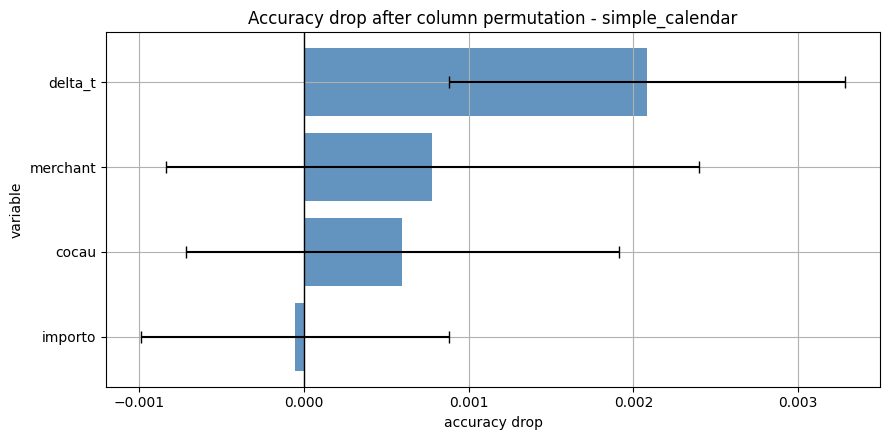

In [3]:
plot_df = result.sort_values('accuracy_drop', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    plot_df['variable'],
    plot_df['accuracy_drop'],
    xerr=plot_df['accuracy_drop_std'],
    color='steelblue',
    ecolor='black',
    alpha=0.85,
    capsize=4,
)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('accuracy drop')
ax.set_ylabel('variable')
ax.set_title('Accuracy drop after column permutation - simple_calendar')
plt.tight_layout()
plt.show()


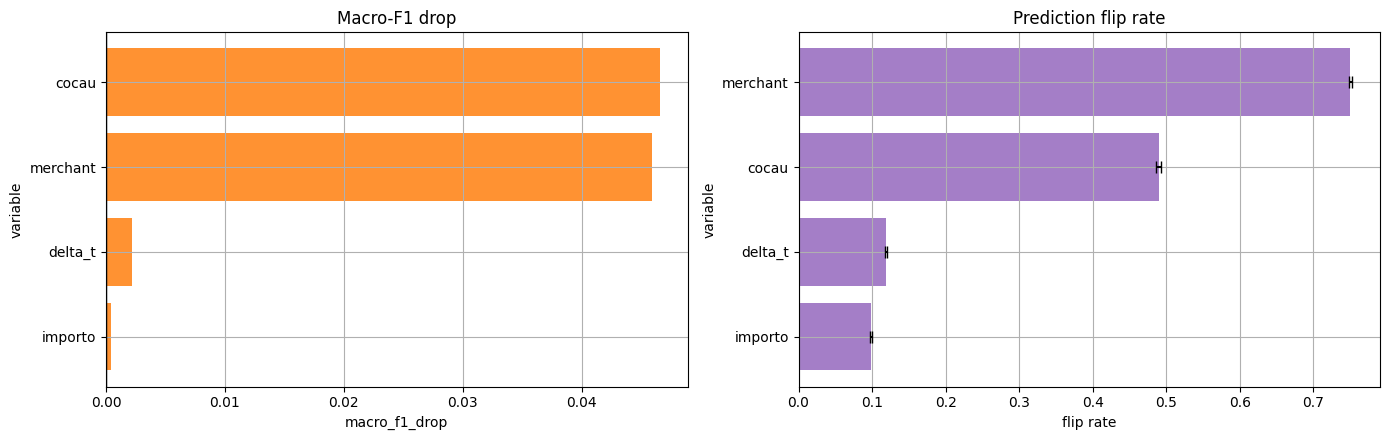

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

metric_df = result.sort_values('macro_f1_drop', ascending=True)
ax[0].barh(metric_df['variable'], metric_df['macro_f1_drop'], color='tab:orange', alpha=0.85)
ax[0].axvline(0, color='black', linewidth=1)
ax[0].set(title='Macro-F1 drop', xlabel='macro_f1_drop', ylabel='variable')

flip_df = result.sort_values('prediction_flip_rate', ascending=True)
ax[1].barh(
    flip_df['variable'],
    flip_df['prediction_flip_rate'],
    xerr=flip_df.get('prediction_flip_rate_std'),
    color='tab:purple',
    alpha=0.85,
    capsize=4,
)
ax[1].set(title='Prediction flip rate', xlabel='flip rate', ylabel='variable')

plt.tight_layout()
plt.show()


## 2. Sintesi e check da controllo negativo

Per quattro cluster bilanciati la chance accuracy e' circa 0.25. La metrica `clean_accuracy_minus_chance` rende esplicito quanto il classificatore riesca a recuperare la label cluster dai clean embedding prima di qualsiasi perturbazione.


In [5]:
n_variables = result['variable'].nunique()
clean_accuracy = result['clean_accuracy'].iloc[0] if len(result) else np.nan
chance_accuracy = 0.25
leader = result.iloc[0] if len(result) else None
runner_up = result.iloc[1] if len(result) > 1 else None
positive_drop_sum = result['accuracy_drop'].clip(lower=0).sum()

summary = pd.DataFrame([
    {
        'n_variables': n_variables,
        'clean_accuracy': clean_accuracy,
        'chance_accuracy_assuming_4_balanced_clusters': chance_accuracy,
        'clean_accuracy_minus_chance': clean_accuracy - chance_accuracy,
        'top_variable': leader['variable'] if leader is not None else np.nan,
        'top_accuracy_drop': leader['accuracy_drop'] if leader is not None else np.nan,
        'top_accuracy_drop_std': leader['accuracy_drop_std'] if leader is not None else np.nan,
        'share_of_positive_drop': (
            leader['accuracy_drop'] / positive_drop_sum
            if leader is not None and positive_drop_sum > 0
            else np.nan
        ),
        'gap_vs_second': (
            leader['accuracy_drop'] - runner_up['accuracy_drop']
            if leader is not None and runner_up is not None
            else np.nan
        ),
    }
])
display(summary)

result.assign(
    relative_to_top=np.where(
        leader is not None and leader['accuracy_drop'] > 0,
        result['accuracy_drop'] / leader['accuracy_drop'],
        np.nan,
    )
)[[
    'variable',
    'clean_accuracy',
    'perturbed_accuracy',
    'accuracy_drop',
    'accuracy_drop_std',
    'relative_to_top',
    'cv',
]]


,n_variables,clean_accuracy,chance_accuracy_assuming_4_balanced_clusters,clean_accuracy_minus_chance,top_variable,top_accuracy_drop,top_accuracy_drop_std,share_of_positive_drop,gap_vs_second
0,4,0.251736,0.250000,0.001736,delta_t,0.002083,0.001200,0.602410,0.001306


,variable,clean_accuracy,perturbed_accuracy,accuracy_drop,accuracy_drop_std,relative_to_top,cv
0,delta_t,0.251736,0.249653,0.002083,0.001200,1.000000,0.576194
1,merchant,0.251736,0.250958,0.000778,0.001618,0.373333,2.079725
2,cocau,0.251736,0.251139,0.000597,0.001315,0.286667,2.202069
3,importo,0.251736,0.251792,-0.000056,0.000933,-0.026667,NaN


## 3. Sensibility drift opzionale

Se hai eseguito anche `uv run py perturbation --type hier --analysis sensibility`, viene letto `model_artifacts/simple_calendar/perturbation.csv`. Il drift misura cambiamento geometrico degli embedding, non capacita' di classificare i cluster; puo' quindi essere alto anche se l'accuracy drop e' basso.


In [6]:
if SENSIBILITY_OUTPUT.exists():
    drift = pd.read_csv(SENSIBILITY_OUTPUT).sort_values('drift', ascending=False).reset_index(drop=True)
    print('Sensibility perturbation report:', SENSIBILITY_OUTPUT)
    display(drift)

    plot_drift = drift.sort_values('drift', ascending=True)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(
        plot_drift['variable'],
        plot_drift['drift'],
        xerr=plot_drift.get('drift_std'),
        color='tab:green',
        ecolor='black',
        alpha=0.85,
        capsize=4,
    )
    ax.set_xlabel('mean cosine drift')
    ax.set_ylabel('variable')
    ax.set_title('Embedding drift after column permutation - simple_calendar')
    plt.tight_layout()
    plt.show()
else:
    print('Optional sensibility report not found:', SENSIBILITY_OUTPUT)


Optional sensibility report not found: /workspaces/be-bper-ai-toolchain-bseq-app/model_artifacts/simple_calendar/perturbation.csv
